# Tutorial 0: Using the model

## Learning objectives

In this tutorial, you will learn how to:
- How to load a pretrained model from the ensemble,
- how to stimulate the model and plot its neural responses,
- and how to update its parameters using gradient descent.

## Introduction

We built a differentiable PyTorch neural network model constrained by the motion pathway
connectome of the fly visual system. We trained our model on the task of optic flow prediction
on the computer vision task Sintel. Since equivalently trained models differed across
runs we characterized statistics across multiple trained models: 

**Model Ensembles**: flyvis includes ensembles of multiple independently trained models of the fly visual system. Each model in the ensemble captures slightly different aspects of neural computation due to different initial conditions or training trajectories. Working with ensembles allows us to characterize findings statistically to test the robustness across multiple models, and to explore alternative explanations.

## Setup

First, let's import the necessary libraries and set up our environment:

In [1]:
# For Google Colab, uncomment and run this cell to install flyvis
# !pip install "git+https://github.com/TuragaLab/flysim_tutorials.git#subdirectory=visual_system_tutorial"

In [2]:
# Run this to download the pretrained model ensemble
# !flyvis download-pretrained

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# flyvis imports
from flyvis import NetworkView
from flyvis.datasets.rendering import BoxEye
from flyvis.analysis.animations import HexScatter, Imshow

# Set up plotting
plt.rcParams["figure.figsize"] = [5, 3]
plt.rcParams["font.size"] = 6
plt.rcParams["figure.dpi"] = 200

## Part 1: Load a pretrained model from the ensemble

Let's start by loading a pretrained model from the ensemble:

In [4]:
# Load a pretrained network model from the ensemble
# The identifier "flow/0000/000" specifies: task/ensemble_id/network_id
# - "flow": the training task (optic flow prediction)
# - "0000": the first ensemble (collection of models trained with same configuration)
# - "000": the first network within that ensemble
network_view = NetworkView("flow/0000/000")

[2025-07-21 12:43:50] network_view:122 Initialized network view at /groups/turaga/home/lappalainenj/FlyVis/flyvis/data/results/flow/0000/000


### Understanding the network architecture

The network models the fly visual system, including different cell types. Let's explore what cell types are available:

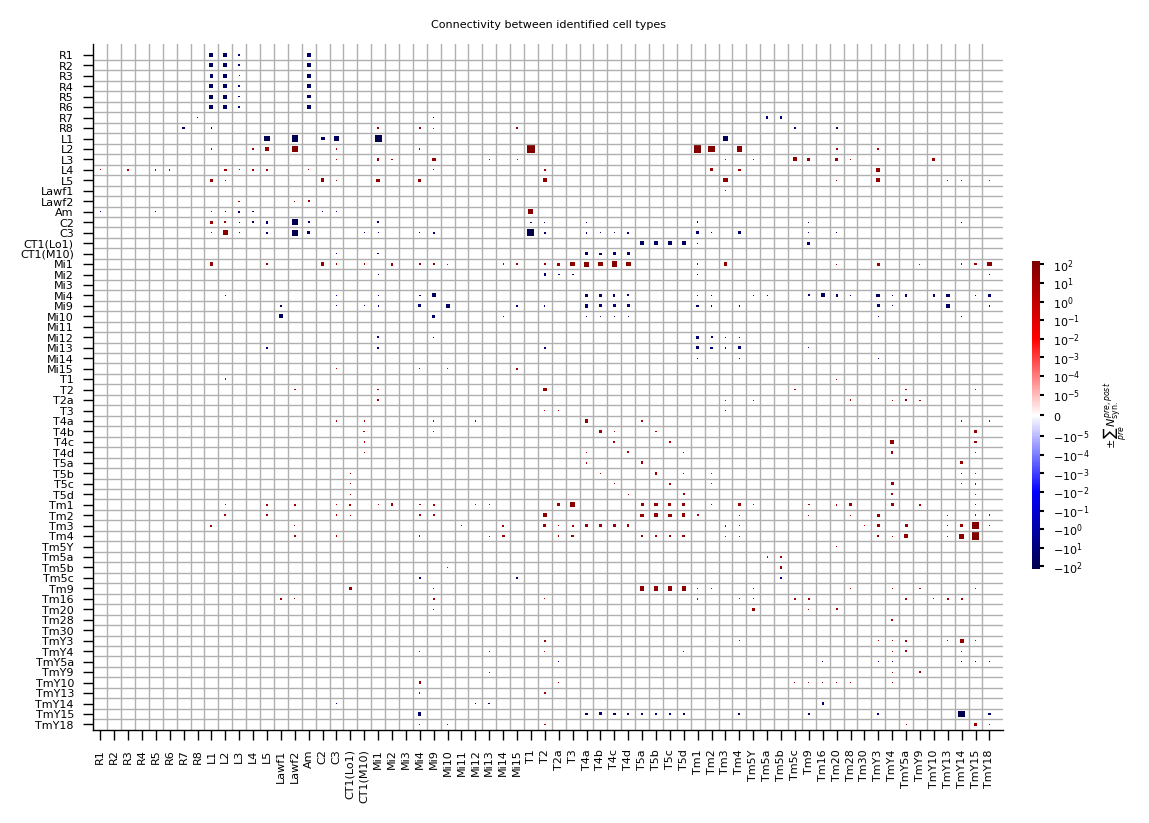

In [5]:
fig = network_view.connectivity_matrix()

In [6]:
# Get information about the network structure
connectome = network_view.connectome
cell_types = connectome.unique_cell_types

print("Available cell types:")
for i, cell_type in enumerate(cell_types):
    print(f"{i + 1:2d}. {cell_type.decode()}")

Available cell types:
 1. R1
 2. R2
 3. R3
 4. R4
 5. R5
 6. R6
 7. R7
 8. R8
 9. L1
10. L2
11. L3
12. L4
13. L5
14. Lawf1
15. Lawf2
16. Am
17. C2
18. C3
19. CT1(Lo1)
20. CT1(M10)
21. Mi1
22. Mi2
23. Mi3
24. Mi4
25. Mi9
26. Mi10
27. Mi11
28. Mi12
29. Mi13
30. Mi14
31. Mi15
32. T1
33. T2
34. T2a
35. T3
36. T4a
37. T4b
38. T4c
39. T4d
40. T5a
41. T5b
42. T5c
43. T5d
44. Tm1
45. Tm2
46. Tm3
47. Tm4
48. Tm5Y


49. Tm5a
50. Tm5b
51. Tm5c
52. Tm9
53. Tm16
54. Tm20
55. Tm28
56. Tm30
57. TmY3
58. TmY4
59. TmY5a
60. TmY9
61. TmY10
62. TmY13
63. TmY14
64. TmY15
65. TmY18


In our model, all presynaptic neurons of the same type project to postsynaptic neurons of the same type in the same way:

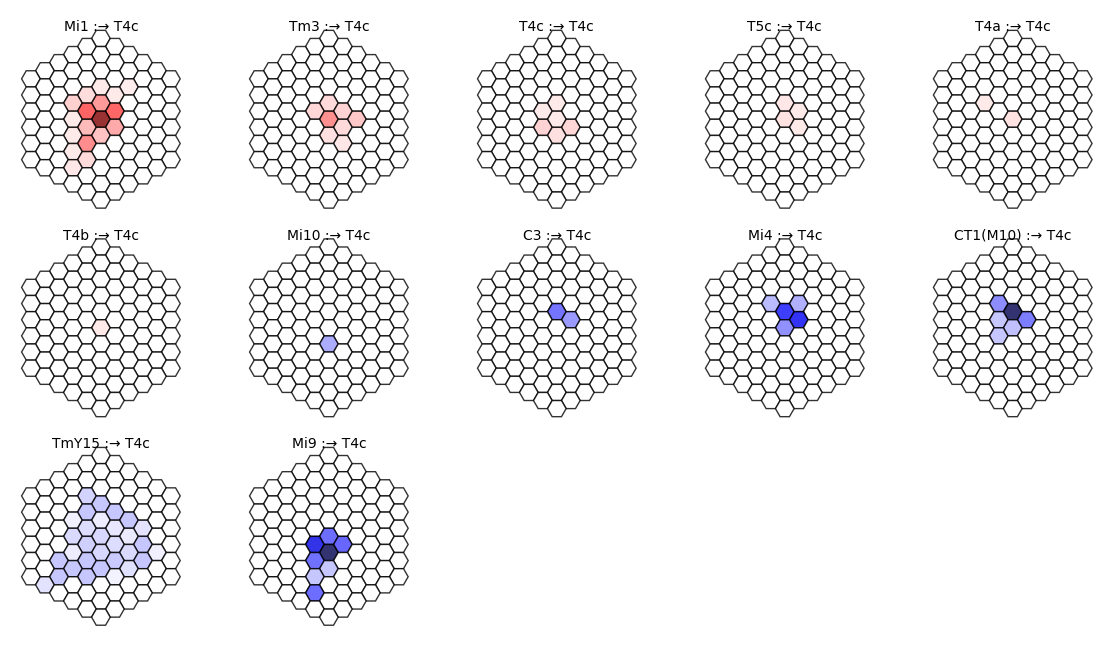

In [7]:
# Plot the anatomical receptive fields onto the central T4c cell in terms of signed
# average number of synapses in retinotopic column space.
fig = network_view.receptive_fields_grid(
    target="T4c",
    panel_height_cm=3,
    panel_width_cm=3.6,
)
plt.subplots_adjust(wspace=0.05, hspace=0.15)

### Loading the differentiable PyTorch model

Let's load the pretrained model:

In [8]:
network_view = NetworkView(
    "flow/0000/000",
    # This loads the model with the best validation loss
    best_checkpoint_fn_kwargs={
        "validation_subdir": "validation",
        "loss_file_name": "loss",
    },
)
network = network_view.init_network()

[2025-07-21 12:44:01] network_view:122 Initialized network view at /groups/turaga/home/lappalainenj/FlyVis/flyvis/data/results/flow/0000/000


[2025-07-21 12:44:10] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.
[2025-07-21 12:44:10] chkpt_utils:36 Recovered network state.


In [9]:
# Print the network configuration
print(network.config)

Namespace(
  connectome = Namespace(
    type = 'ConnectomeFromAvgFilters',
    file = 'fib25-fib19_v2.2.json',
    extent = 15,
    n_syn_fill = 1
  ),
  dynamics = Namespace(
    type = 'PPNeuronIGRSynapses',
    activation = Namespace(type='relu')
  ),
  node_config = Namespace(
    bias = Namespace(
      type = 'RestingPotential',
      groupby = ['type'],
      initial_dist = 'Normal',
      mode = 'sample',
      requires_grad = True,
      mean = 0.5,
      std = 0.05,
      penalize = Namespace(activity=True),
      seed = 0
    ),
    time_const = Namespace(
      type = 'TimeConstant',
      groupby = ['type'],
      initial_dist = 'Value',
      value = 0.05,
      requires_grad = True
    )
  ),
  edge_config = Namespace(
    sign = Namespace(
      type = 'SynapseSign',
      initial_dist = 'Value',
      requires_grad = False,
      groupby = ['source_type', 'target_type']
    ),
    syn_count = Namespace(
      type = 'SynapseCount',
      initial_dist = 'Lognormal',
  

In [10]:
# Print the network parameters
for name, param in network.named_parameters():
    print(name, param.shape)

nodes_bias torch.Size([65])
nodes_time_const torch.Size([65])
edges_sign torch.Size([604])
edges_syn_count torch.Size([2355])
edges_syn_strength torch.Size([604])


## Part 2: Stimulate the model and plot its neural responses

Let's understand how to stimulate the model:

In [11]:
from flyvis.utils.hex_utils import get_num_hexals

# Stimulation time and time step
T = 1  # seconds
dt = 1 / 50  # 1 / 200

# Create a random stimulus
stimulus = torch.randn(
    1, int(T / dt), 1, get_num_hexals(network.connectome.config.extent)
)

# Add the stimulus to a stimulus buffer
network.stimulus.add_input(stimulus)

# Run the model
with torch.no_grad():
    network_activity = network(network.stimulus(), dt=dt)

In [12]:
print("Shape of the network activity:", network_activity.shape)

Shape of the network activity: torch.Size([1, 50, 45669])


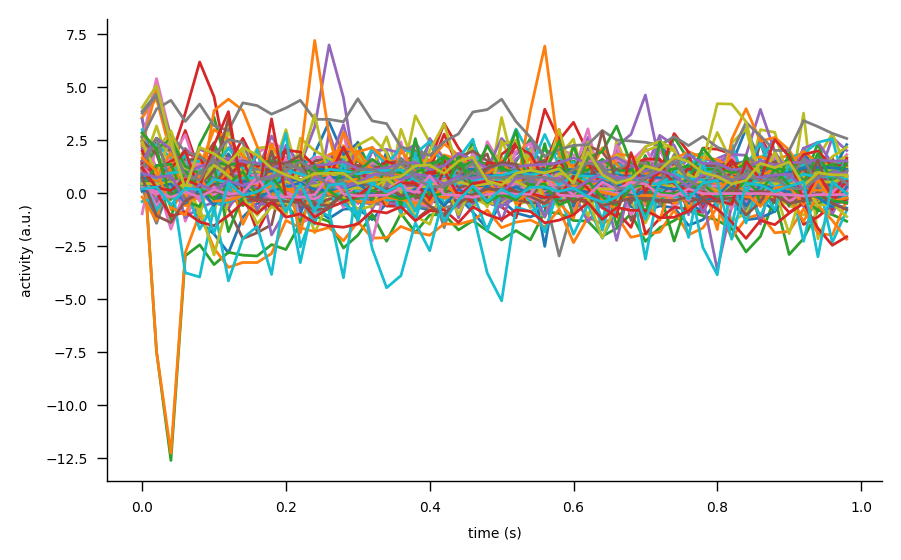

In [13]:
random_neuron_idx = torch.randint(0, network_activity.shape[-1], (100,)).to()
time = np.arange(0, network_activity.shape[1]) * dt

plt.plot(time, network_activity[0, :, random_neuron_idx].detach().cpu().numpy())
plt.xlabel("time (s)")
plt.ylabel("activity (a.u.)")
plt.show()

Let's visualize one representative trace per cell type:

In [14]:
from flyvis.utils.activity_utils import LayerActivity as ActivityByType

In [15]:
activity_by_type = ActivityByType(network_activity, network.connectome, keepref=True)

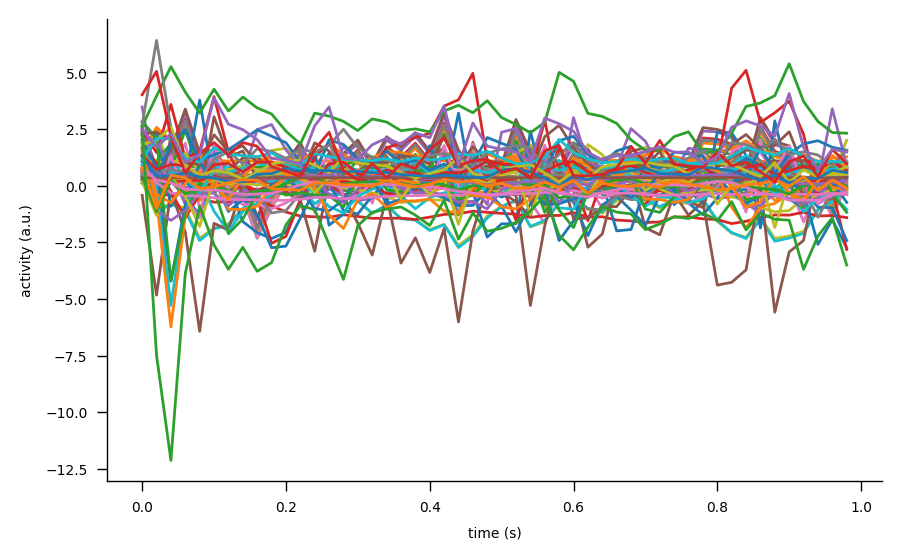

In [16]:
random_neuron_idx = torch.randint(0, network_activity.shape[-1], (100,)).to()
time = np.arange(0, network_activity.shape[1]) * dt

plt.plot(time, activity_by_type.central[:].squeeze().cpu())
plt.xlabel("time (s)")
plt.ylabel("activity (a.u.)")
plt.show()

For rendering custom video stimuli, we need to load cartesian frames and render them to hexagonal coordinates:

In [17]:
def get_cool_stimulus_movie():
    import numpy as np

    # Parameters for the movie
    num_frames = 100
    height, width = 400, 700  # Cartesian grid size

    # Parameters for standing 2D waves
    num_waves = np.random.randint(4, 8)  # number of standing waves to superimpose
    frames = np.zeros((num_frames, height, width), dtype=np.float32)

    yy, xx = np.meshgrid(np.arange(height), np.arange(width), indexing="ij")

    # Randomize wave parameters
    wave_params = []
    for _ in range(num_waves):
        # Random spatial frequencies (cycles per image)
        fx = np.random.uniform(0.5, 3.0)
        fy = np.random.uniform(0.5, 3.0)
        # Random phase offset
        phase0 = np.random.uniform(0, 2 * np.pi)
        # Random temporal frequency (cycles per movie)
        temporal_freq = np.random.uniform(0.5, 2.0)
        wave_params.append((fx, fy, phase0, temporal_freq))

    for t in range(num_frames):
        frame = np.zeros((height, width), dtype=np.float32)
        for fx, fy, phase0, temporal_freq in wave_params:
            # Standing wave: sin(kx x) * sin(ky y) * cos(w t + phase)
            spatial = np.sin(2 * np.pi * fx * xx / width) * np.sin(
                2 * np.pi * fy * yy / height
            )
            temporal = np.cos(2 * np.pi * temporal_freq * t / num_frames + phase0)
            frame += spatial * temporal
        # Normalize to [0, 1]
        frame = (frame - frame.min()) / (frame.max() - frame.min() + 1e-8)
        frames[t] = frame
    return frames

In [18]:
# Let's create a custom stimulus
frames = get_cool_stimulus_movie()

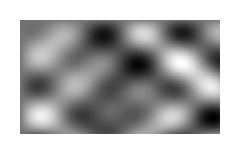

In [19]:
# Let's visualize the stimulus
anim = Imshow(frames[None], cmap=plt.cm.binary_r)
anim.animate_in_notebook()

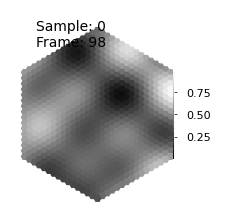

In [20]:
# Let's render the stimulus movie in hexagonal coordinates and visualize it
renderer = BoxEye(network.connectome.config.extent, kernel_size=13)
hex_frames = renderer(frames[None])
anim = HexScatter(hex_frames)
anim.animate_in_notebook(frames=np.arange(hex_frames.shape[1])[::2])

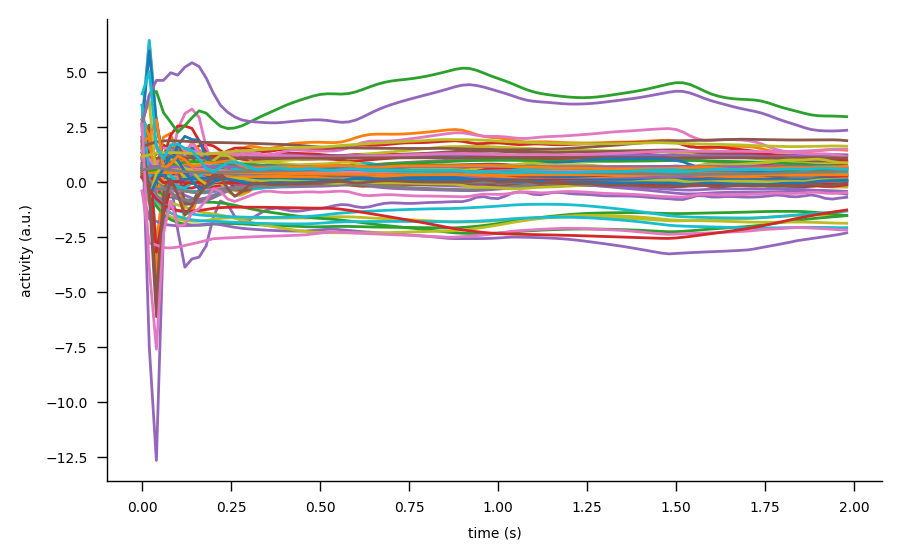

In [21]:
# Reset the stimulus buffer
network.stimulus.zero()

# Add the stimulus to a stimulus buffer
network.stimulus.add_input(hex_frames)

# Run the model
with torch.no_grad():
    network_activity = network(network.stimulus(), dt=dt)

# Let's visualize 100 random neurons
random_neuron_idx = torch.randint(0, network_activity.shape[-1], (100,)).to()
time = np.arange(0, network_activity.shape[1]) * dt

plt.plot(time, network_activity[0, :, random_neuron_idx].detach().cpu().numpy())
plt.xlabel("time (s)")
plt.ylabel("activity (a.u.)")
plt.show()

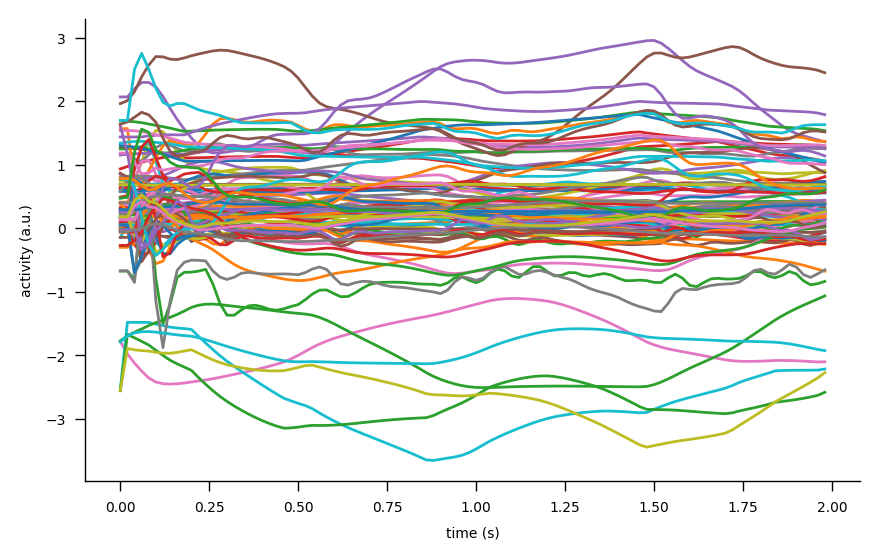

In [22]:
# Let's reduce the initial transient response by using the steady state as initial state

initial_state = network.steady_state(t_pre=1.0, dt=dt, batch_size=1)

# Reset the stimulus buffer
network.stimulus.zero()

# Add the stimulus to a stimulus buffer
network.stimulus.add_input(hex_frames)

# Run the model
with torch.no_grad():
    network_activity = network(network.stimulus(), dt=dt, state=initial_state)

# Let's visualize 100 random neurons
random_neuron_idx = torch.randint(0, network_activity.shape[-1], (100,)).to()
time = np.arange(0, network_activity.shape[1]) * dt

plt.plot(time, network_activity[0, :, random_neuron_idx].detach().cpu().numpy())
plt.xlabel("time (s)")
plt.ylabel("activity (a.u.)")
plt.show()

## Part 3: Gradient-descent on the model

Now let's explore how to update the model parameters using gradient descent. Useful for training or fine-tuning the model on new data.

We'll try to increase the response of a specific neuron to our stimulus.

In [23]:
# Let's create a simple training scenario
# We'll try to increase the response of T4c neurons to our custom stimulus

# First, let's reinitialize the network to ensure we have gradients enabled
network_view = NetworkView(
    "flow/0000/000",
    best_checkpoint_fn_kwargs={
        "validation_subdir": "validation",
        "loss_file_name": "loss",
    },
)
network = network_view.init_network()

# Make sure gradients are enabled for the parameters we want to optimize
for name, param in network.named_parameters():
    if param.requires_grad:
        print(f"{name} is trainable")

# Set up an optimizer
optimizer = torch.optim.Adam(network.parameters(), lr=0.001)

[2025-07-21 12:45:15] network_view:122 Initialized network view at /groups/turaga/home/lappalainenj/FlyVis/flyvis/data/results/flow/0000/000


[2025-07-21 12:45:24] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.
[2025-07-21 12:45:24] chkpt_utils:36 Recovered network state.


nodes_bias is trainable
nodes_time_const is trainable
edges_syn_strength is trainable


In [24]:
# Let's look at the free T4c neuron parameters pre training
print(
    "T4c time_const (pre-trained):",
    f"{network.node_params.time_const['T4c'].item() * 1000: .0f} ms",
)
print("T4c bias (pre-trained):", f"{network.node_params.bias['T4c'].item():.2f}")

T4c time_const (pre-trained):  20 ms
T4c bias (pre-trained): 0.68


In [25]:
# Let's look at the free T4c input parameters, alpha_{t_i, t_j}
print(
    "T4c input scalings:\n",
)
for e in network.edge_params.syn_strength.keys:
    if e[1] == "T4c":
        print(f"{e[0]} input scaling:", f"{network.edge_params.syn_strength[e]:.8f}")

T4c input scalings:

C3 input scaling: 0.01486829
CT1(M10) input scaling: 0.01113249
Mi1 input scaling: 0.02413530
Mi4 input scaling: 0.05615869
Mi9 input scaling: 0.01958211
Mi10 input scaling: 0.07800332
T4a input scaling: 0.03211476
T4b input scaling: 0.06058843
T4c input scaling: 0.06498163
T5c input scaling: 0.02940214
Tm3 input scaling: 0.00002163
TmY15 input scaling: 0.01466804


In [26]:
# Create a target stimulus - let's use our random stimulus from before
dt = 1 / 50
T = 1
stimulus = torch.randn(
    1, int(T / dt), 1, get_num_hexals(network.connectome.config.extent)
)

# Find T4c neurons (we'll focus on the central ones)
t4c_indices = network.connectome.nodes.to_df().query("type == 'T4c'").index
central_t4c_idx = t4c_indices[len(t4c_indices) // 2]  # Get a central T4c neuron

print(f"Focusing on T4c neuron at index: {central_t4c_idx}")
print(f"Total T4c neurons: {len(t4c_indices)}")

# Get initial response (before training)
network.stimulus.zero(stimulus.shape[0], stimulus.shape[1])
network.stimulus.add_input(stimulus)

with torch.no_grad():
    pretrained_activity = network(network.stimulus(), dt=dt)
    pretrained_t4c_response = pretrained_activity[0, :, central_t4c_idx]
    pretrained_peak_response = torch.max(pretrained_t4c_response).item()

print(f"Initial T4c response peak: {pretrained_peak_response:.2f}")


Focusing on T4c neuron at index: 25841
Total T4c neurons: 721
Initial T4c response peak: 2.01


In [27]:
# Training step to increase T4c response to our custom stimulus

# Clear gradients
optimizer.zero_grad()

# Forward pass
network.stimulus.add_input(stimulus)
activity = network(network.stimulus(), dt=dt)

# Get T4c response
t4c_response = activity[0, :, central_t4c_idx]

# Calculate loss as the peak response
loss = -torch.max(t4c_response)

# Backward pass
loss.backward()

# Update parameters
optimizer.step()

In [28]:
# Create a target stimulus - let's use our random stimulus from before
dt = 1 / 50
T = 1
stimulus = torch.randn(
    1, int(T / dt), 1, get_num_hexals(network.connectome.config.extent)
)

# Find T4c neurons (we'll focus on the central ones)
t4c_indices = network.connectome.nodes.to_df().query("type == 'T4c'").index
central_t4c_idx = t4c_indices[len(t4c_indices) // 2]  # Get a central T4c neuron

print(f"Focusing on T4c neuron at index: {central_t4c_idx}")
print(f"Total T4c neurons: {len(t4c_indices)}")

# Get initial response (before training)
network.stimulus.zero(stimulus.shape[0], stimulus.shape[1])
network.stimulus.add_input(stimulus)

with torch.no_grad():
    pretrained_activity = network(network.stimulus(), dt=dt)
    pretrained_t4c_response = pretrained_activity[0, :, central_t4c_idx]
    pretrained_peak_response = torch.max(pretrained_t4c_response).item()

print(f"Initial T4c response peak: {pretrained_peak_response:.2f}")


Focusing on T4c neuron at index: 25841
Total T4c neurons: 721
Initial T4c response peak: 2.14


In [29]:
# Let's look at the free T4c neuron parameters pre training
print(
    "T4c time_const (pre-trained):",
    f"{network.node_params.time_const['T4c'].item() * 1000: .0f} ms",
)
print("T4c bias (pre-trained):", f"{network.node_params.bias['T4c'].item():.2f}")

T4c time_const (pre-trained):  20 ms
T4c bias (pre-trained): 0.68


In [30]:
# Let's look at the free T4c input parameters, alpha_{t_i, t_j}
print(
    "T4c input scalings:\n",
)
for e in network.edge_params.syn_strength.keys:
    if e[1] == "T4c":
        print(f"{e[0]} input scaling:", f"{network.edge_params.syn_strength[e]:.8f}")

T4c input scalings:

C3 input scaling: 0.01386829
CT1(M10) input scaling: 0.01013249
Mi1 input scaling: 0.02513530
Mi4 input scaling: 0.05515869
Mi9 input scaling: 0.01858211
Mi10 input scaling: 0.07700332
T4a input scaling: 0.03311476
T4b input scaling: 0.06158843
T4c input scaling: 0.06598163
T5c input scaling: 0.03040214
Tm3 input scaling: 0.00102163
TmY15 input scaling: 0.01366804


### 🤔 Discussion Questions

1. Which parameters differ after the gradient update?
2. What could this tell us about T4c inputs and function?
3. What could be other parameter changes that might increase the T4c response?

## Summary

In this tutorial, you've learned to:

1. **Load and work with the pretrained network model** of the fly visual system
2. **Stimulate the model** with custom inputs and visualize neural responses
3. **Update model parameters** using gradient descent to optimize neural responses

### Key Insights

- `flyvis` provides pretrained connectome-constrained neural network models of the fly visual system
- Neurons in the model correspond to neurons in the fly visual system
- You can stimulate the models with custom inputs and observe neural dynamics
- Gradient descent can be used to fine-tune model parameters for specific objectives

### Next Steps

In the next tutorial, we'll explore deep stimulus design techniques to find optimal stimuli that maximally activate specific neurons and reveal computational principles.

## Supporting references

**General:**

Flyvis Documentation. https://turagalab.github.io/flyvis/.  
Lappalainen, J. K. et al. Connectome-constrained networks predict neural activity across the fly visual system. Nature 634, 1132–1140 (2024).  